In [1]:
import numpy as np
import pandas as pd

%matplotlib inline
import matplotlib.pyplot as plt

events = pd.read_csv("events.dat", sep=" ")
events["chirp_mass"] = (events["mass_1"] * events["mass_2"])**0.6 / (events["mass_1"] + events["mass_2"])**0.2
events["mass_ratio"] = events["mass_2"] / events["mass_1"]

(array([ 1.,  1.,  0.,  0.,  4.,  6.,  3.,  7., 14., 15.]),
 array([0.72582053, 0.75278112, 0.77974172, 0.80670231, 0.8336629 ,
        0.86062349, 0.88758408, 0.91454467, 0.94150526, 0.96846585,
        0.99542644]),
 <BarContainer object of 10 artists>)

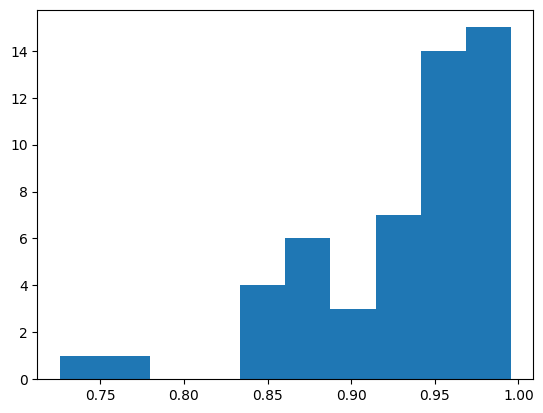

In [2]:
plt.hist(events["mass_ratio"])

In [3]:
def quantile_list(key):
    quantiles = np.zeros(51)
    for j in range(51):
    
        posterior = np.load(f"gw_posteriors/source_{j}/posterior.npz")
    
        quantiles[j] = np.sum(posterior[key]<=events.loc[j, key]) / posterior[key].shape[0]

    return quantiles

quantiles = quantile_list("mass_1_source")
quantiles_detector = quantile_list("mass_1")
quantiles_chirp = quantile_list('chirp_mass')
quantiles_mass_ratio = quantile_list('mass_ratio')

Text(0.5, 0, 'chirp mass quantiles')

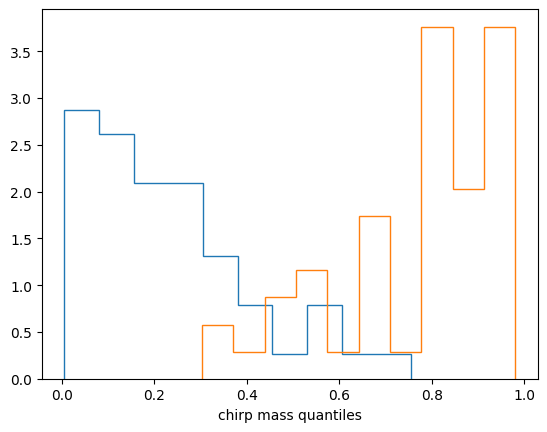

In [4]:

plt.hist(quantiles_chirp, histtype="step", density=True)
plt.hist(quantiles_mass_ratio, histtype="step", density=True)
plt.xlabel("chirp mass quantiles")

In [10]:
inds = quantiles_mass_ratio.argsort()
print(inds)

[27 31 32 22 48 47 24 43 14 21 49 20 28  7 35 15 33  8 40 42  2 37  1  9
 17 23 29  5  4 26 39 41 44 19  6  0 12 30 11 36 34 25  3 38 18 13 16 50
 46 45 10]


In [6]:
np.sort(quantiles_mass_ratio)

array([0.30300073, 0.31174858, 0.40320878, 0.46422697, 0.48242147,
       0.4968815 , 0.50898064, 0.55817579, 0.56881533, 0.57216389,
       0.63034236, 0.64484848, 0.64896016, 0.64942792, 0.6522    ,
       0.66201174, 0.66374635, 0.76751592, 0.78117647, 0.78763686,
       0.79305263, 0.79691269, 0.79746549, 0.80779433, 0.82117848,
       0.8235984 , 0.82755458, 0.82862394, 0.83012512, 0.83490877,
       0.83790876, 0.85738326, 0.87411032, 0.8842125 , 0.88903143,
       0.89087397, 0.9002826 , 0.91186593, 0.91575263, 0.91634017,
       0.92284569, 0.92452026, 0.93571149, 0.94259589, 0.95156527,
       0.95314735, 0.96501726, 0.96874266, 0.96980871, 0.97308647,
       0.98032678])

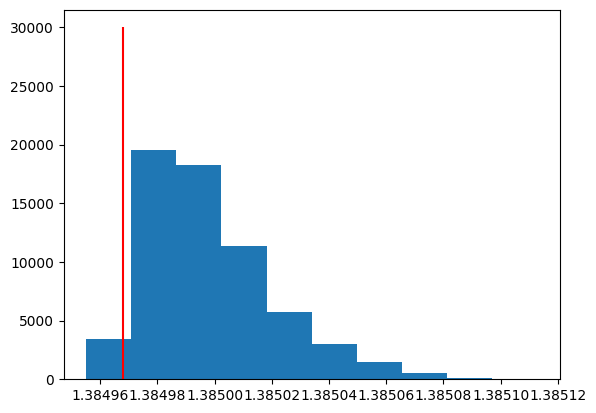

In [7]:
posterior = np.load("./gw_posteriors/source_42/posterior.npz")
plt.hist(posterior["chirp_mass"], density=True)
plt.vlines([events.loc[42, "chirp_mass"]], 0, 30_000, color="red")

In [19]:
from jesterTOV.inference.transforms import MultimessengerJesterTransform
from jesterTOV.utils import solar_mass_in_meter

from nmma.core.conversion import BNSEjectaFitting

/home/koehn1/miniconda3/envs/nmma_x_fiesta/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [22]:
mass_1 = events.loc[22, "mass_1_source"]
mass_2 = events.loc[22, "mass_2_source"]
radius_1 = events.loc[22, "radius_1"]
radius_2 = events.loc[22, "radius_2"]
compactness_1 = mass_1 / radius_1 * solar_mass_in_meter * 1e-3
compactness_2 = mass_2 / radius_2 * solar_mass_in_meter * 1e-3

log10_mej_dyn = np.log10(MultimessengerJesterTransform.dynamic_mass_fitting(mass_1, mass_2, compactness_1, compactness_2))

In [23]:
print(log10_mej_dyn, events.loc[22, "log10_mej_dyn"])

-2.235712866528109 -2.235648111224239


In [31]:
import jax

jax.random.uniform(jax.random.key(57191), shape=(10,), minval=1.32, maxval=1.2)

Array([1.32, 1.32, 1.32, 1.32, 1.32, 1.32, 1.32, 1.32, 1.32, 1.32],      dtype=float64)

In [22]:
events["mass_ratio"].min()

np.float64(0.7258205335293277)